<a href="https://colab.research.google.com/github/Hemang-Dave/ML-and-Deep-Learning/blob/DS%2FML/ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

data_url = "https://raw.githubusercontent.com/shala2020/shala2020.github.io/master/Lecture_Materials/Assignments/MachineLearning/L1/attrition.csv"
attrition_data = pd.read_csv(data_url)


In [ ]:
cat_cols = attrition_data.select_dtypes(include=['object', 'string']).columns
df_encoded = pd.get_dummies(attrition_data, columns=cat_cols, dummy_na=False)

EDA

Number of attritions:  172


/tmp/ipython-input-2848513266.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned)[attrition_col].value_counts(normalize=True).unstack()
/tmp/ipython-input-2848513266.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned)[attrition_col].value_counts(normalize=True).unstack()
/tmp/ipython-input-2848513266.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped =

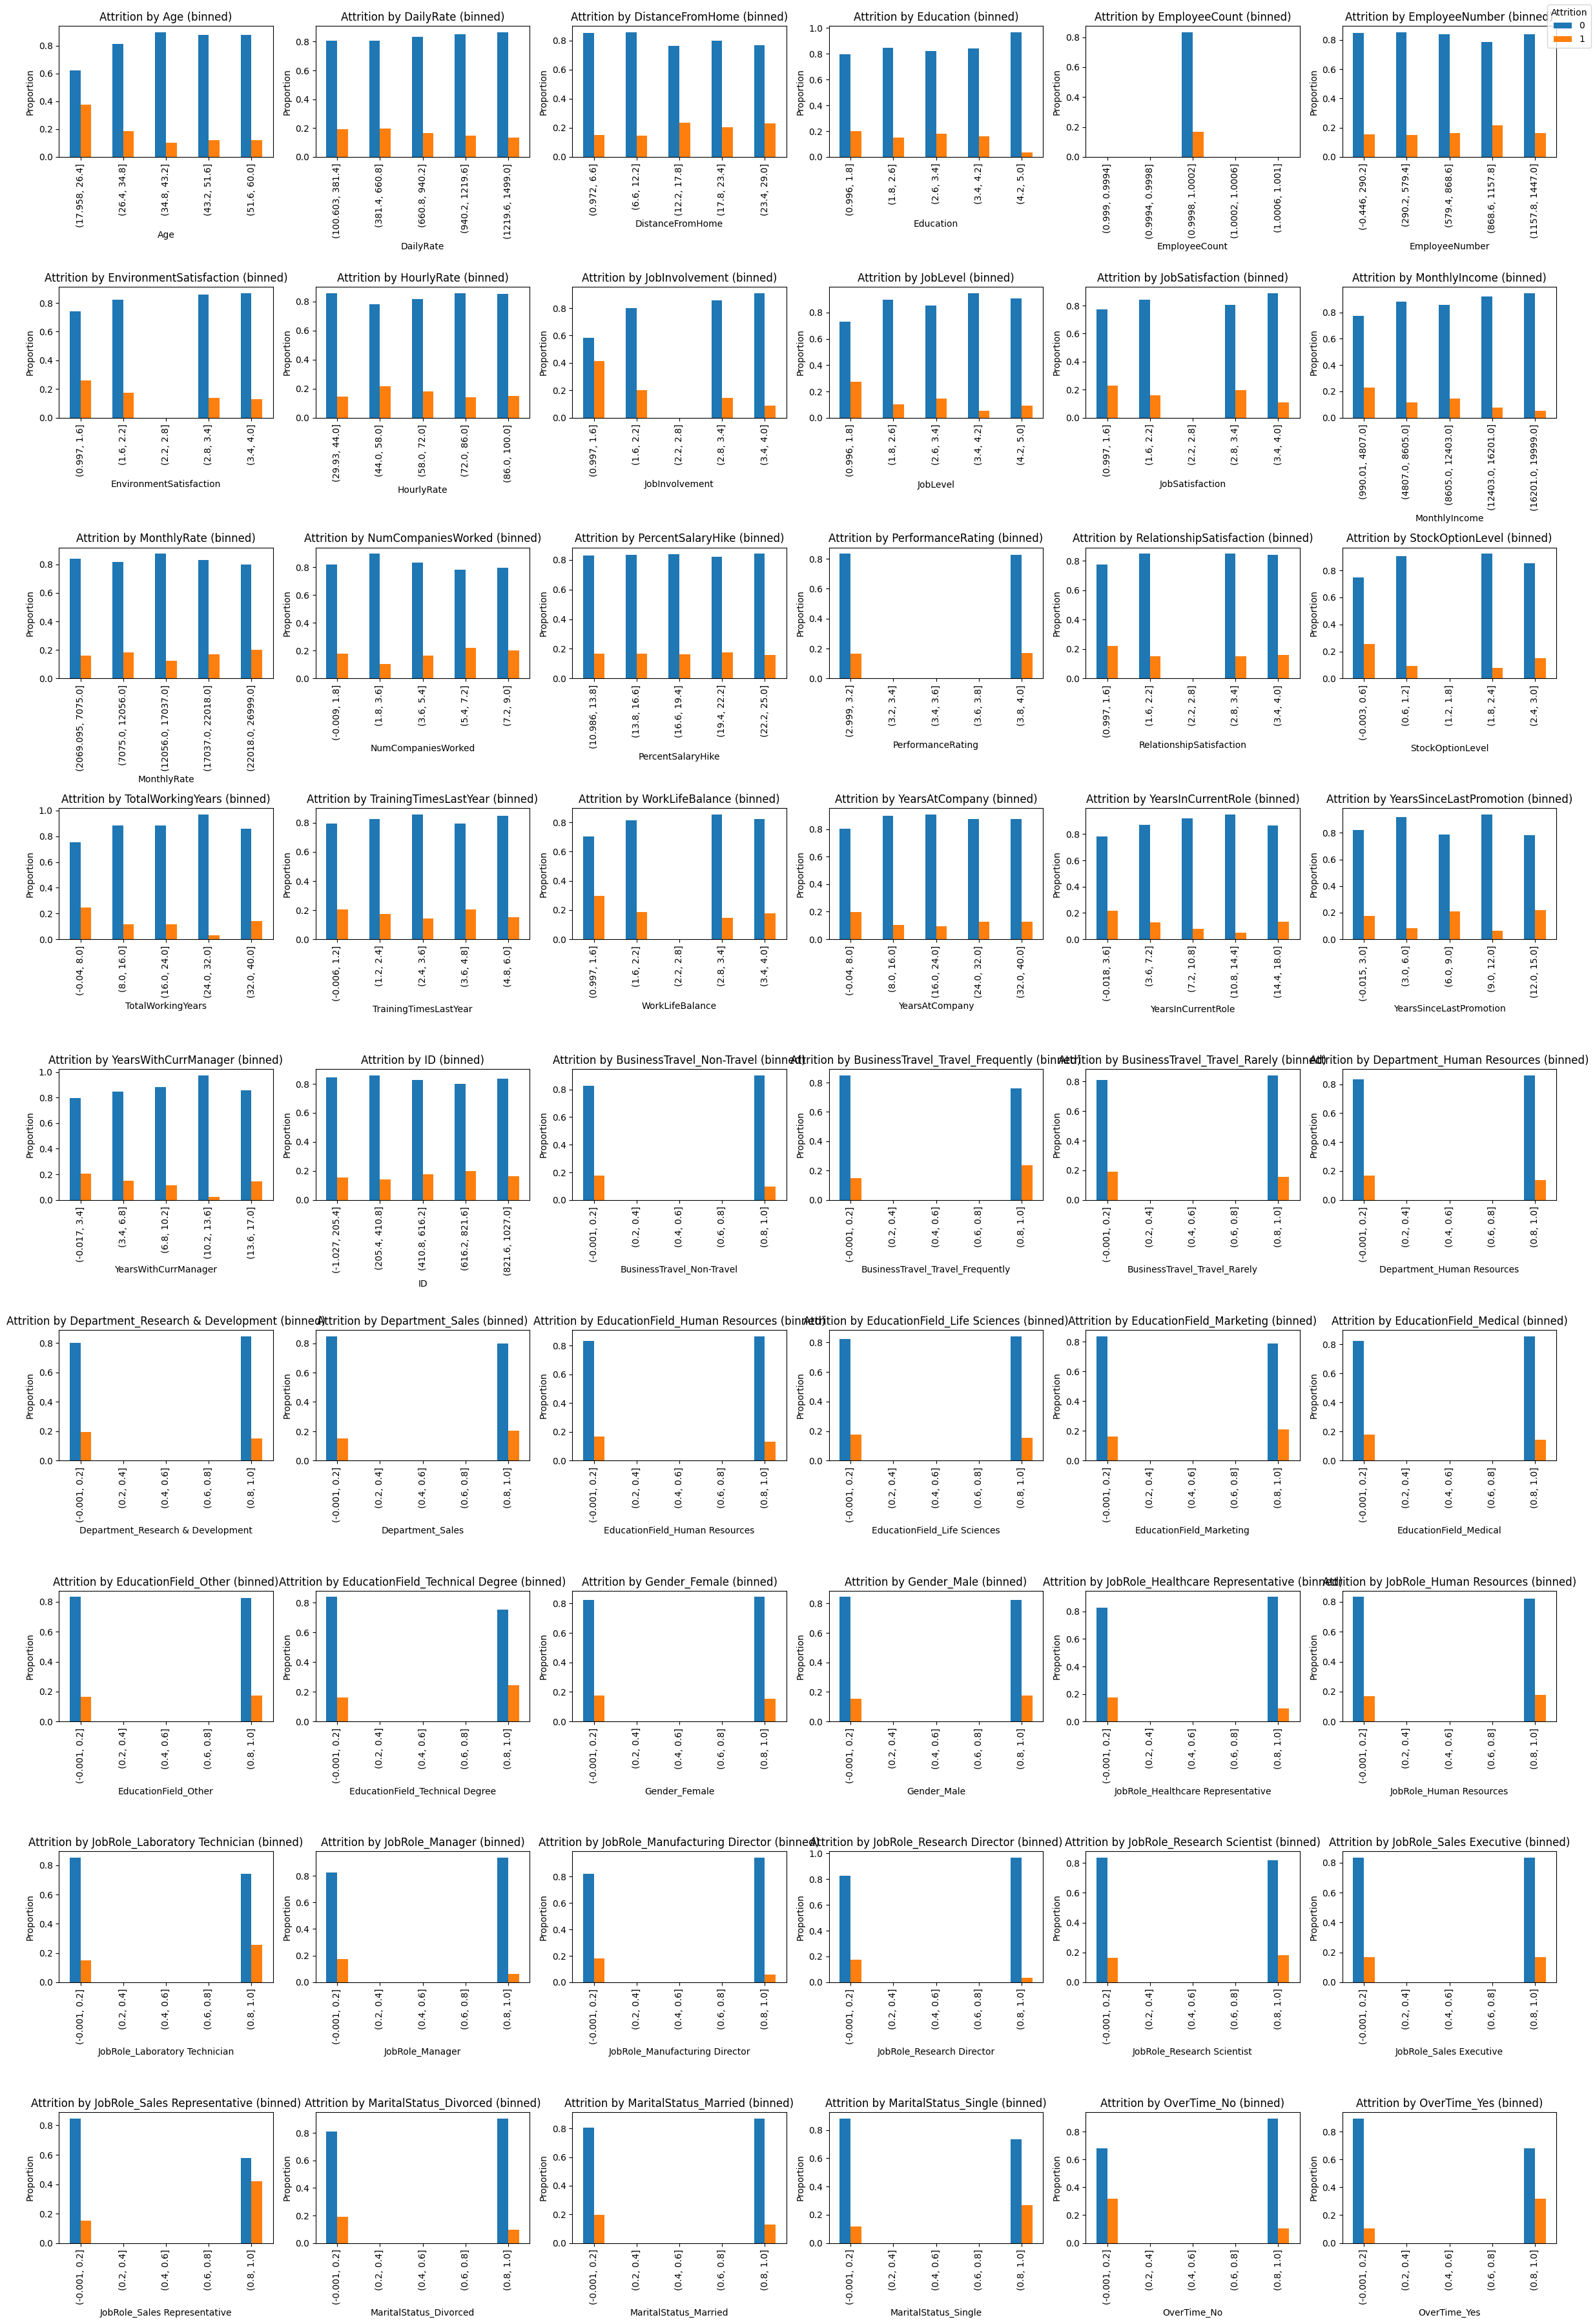

In [20]:
print('Number of attritions: ', attrition_data['Attrition'].sum())


def plot_attrition_vs_all_grid(df, attrition_col="Attrition", charts_per_row=6):
    """
    Creates a grid of bar charts comparing the attrition column
    with every other column in the DataFrame.
    """

    # Ensure the attrition column exists
    if attrition_col not in df.columns:
        raise ValueError(f"Column '{attrition_col}' not found in DataFrame.")

    other_cols = [col for col in df.columns if col != attrition_col]
    num_cols = len(other_cols)

    # Determine grid layout
    rows = math.ceil(num_cols / charts_per_row)

    fig, axes = plt.subplots(rows, charts_per_row, figsize=(charts_per_row * 4, rows * 4))
    axes = axes.flatten()  # flatten in case of 2D array

    for idx, col in enumerate(other_cols):
        ax = axes[idx]

        if df[col].dtype in ["object", "string", "category"]:
            # --- Categorical columns ---
            grouped = df.groupby(col)[attrition_col].value_counts(normalize=True).unstack()
            grouped.plot(kind="bar", ax=ax, legend=False)
            ax.set_title(f"Attrition by {col}")
            ax.set_ylabel("Proportion")
            ax.set_xlabel(col)

        else:
            # --- Numeric columns ---
            binned = pd.cut(df[col], bins=5)
            grouped = df.groupby(binned)[attrition_col].value_counts(normalize=True).unstack()
            grouped.plot(kind="bar", ax=ax, legend=False)
            ax.set_title(f"Attrition by {col} (binned)")
            ax.set_ylabel("Proportion")
            ax.set_xlabel(col)

    # Turn off unused axes (in case num_cols % charts_per_row != 0)
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    # Add global legend once
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title=attrition_col, loc='upper right')

    plt.tight_layout()
    plt.show()



plot_attrition_vs_all_grid(df_encoded, attrition_col="Attrition", charts_per_row=6)


Classification

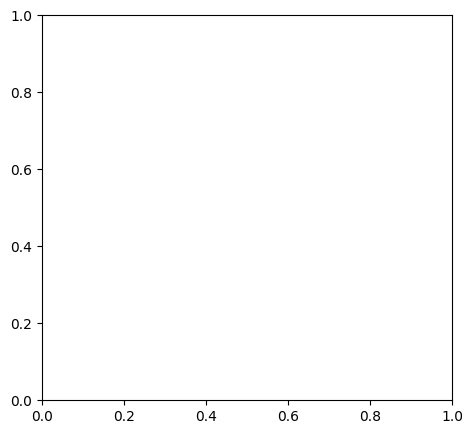

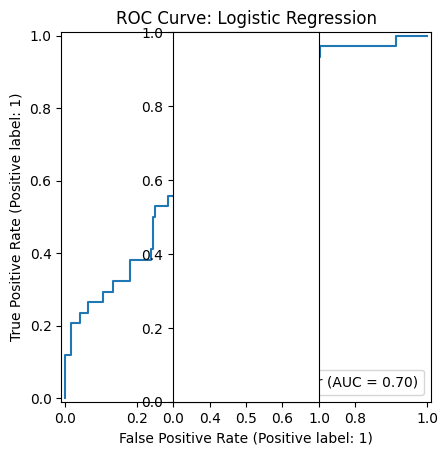

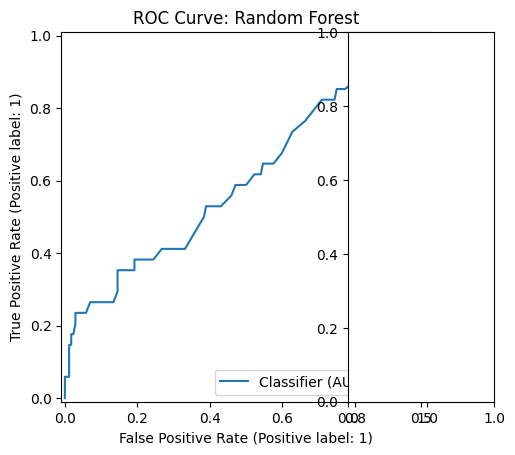

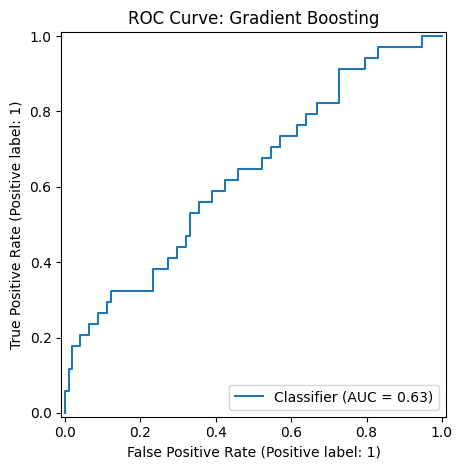


===== Model Performance Summary =====

Model: Logistic Regression
  Accuracy:         0.8495
  Precision:        0.6364
  ROC-AUC:          0.6990
  Confusion Matrix:
[[168   4]
 [ 27   7]]

Model: Random Forest
  Accuracy:         0.8398
  Precision:        0.6667
  ROC-AUC:          0.6036
  Confusion Matrix:
[[171   1]
 [ 32   2]]

Model: Gradient Boosting
  Accuracy:         0.8350
  Precision:        0.5000
  ROC-AUC:          0.6339
  Confusion Matrix:
[[166   6]
 [ 28   6]]

 Best Model: **Logistic Regression** (AUC = 0.6990)


({'Logistic Regression': {'accuracy': 0.8495145631067961,
   'precision': 0.6363636363636364,
   'auc': np.float64(0.6990424076607388),
   'confusion_matrix': array([[168,   4],
          [ 27,   7]])},
  'Random Forest': {'accuracy': 0.8398058252427184,
   'precision': 0.6666666666666666,
   'auc': np.float64(0.6036251709986322),
   'confusion_matrix': array([[171,   1],
          [ 32,   2]])},
  'Gradient Boosting': {'accuracy': 0.8349514563106796,
   'precision': 0.5,
   'auc': np.float64(0.633891928864569),
   'confusion_matrix': array([[166,   6],
          [ 28,   6]])}},
 'Logistic Regression')

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

def run_attrition_classifiers(df, target_col="Attrition"):

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Identify numeric and categorical columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns

    # Preprocessing: scale numeric + one-hot encode categorical
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # -------------------------------
    # 2. Define Classifiers
    # -------------------------------
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.ensemble import GradientBoostingClassifier

    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=200),
        "Random Forest": RandomForestClassifier(n_estimators=200),
        "Gradient Boosting": GradientBoostingClassifier()
    }

    results = {}

    # -------------------------------
    # 3. Fit and Evaluate Each Model
    # -------------------------------
    plt.figure(figsize=(18, 5))

    for idx, (name, model) in enumerate(classifiers.items(), start=1):

        pipe = Pipeline(steps=[
            ('preprocess', preprocessor),
            ('model', model)
        ])

        # Train
        pipe.fit(X_train, y_train)

        # Predict
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            "accuracy": acc,
            "precision": prec,
            "auc": auc,
            "confusion_matrix": cm
        }

        # Plot ROC curve
        plt.subplot(1, 3, idx)
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve: {name}")

    plt.tight_layout()
    plt.show()

    # -------------------------------
    # 4. Print Metrics
    # -------------------------------
    print("\n===== Model Performance Summary =====\n")
    for name, metrics in results.items():
        print(f"Model: {name}")
        print(f"  Accuracy:         {metrics['accuracy']:.4f}")
        print(f"  Precision:        {metrics['precision']:.4f}")
        print(f"  ROC-AUC:          {metrics['auc']:.4f}")
        print(f"  Confusion Matrix:\n{metrics['confusion_matrix']}\n")

    # -------------------------------
    # 5. Determine Best Model
    # -------------------------------
    best = max(results.items(), key=lambda x: x[1]['auc'])
    print(f" Best Model: **{best[0]}** (AUC = {best[1]['auc']:.4f})")

    return results, best[0]

run_attrition_classifiers(df_encoded)